<a href="https://colab.research.google.com/github/Habu2006/Crai-excercise/blob/main/Matploib_%26_Searbon_Practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/insurance.csv')

# Display the first few rows of the DataFrame to verify
print(df.head())

  age     sex     bmi  children smoker     region      charges
0  19  female  27.900       0.0    yes  southwest  16884.92400
1  18    male  33.770       1.0     no  southeast   1725.55230
2  28    male  33.000       3.0     no  southeast   4449.46200
3  33    male  22.705       0.0     no  northwest  21984.47061
4  32    male  28.880       0.0     no  northwest   3866.85520


### Data Cleaning: Inspecting and Handling Missing Values and Data Types

In [ ]:
# Display information about the DataFrame, including data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1339 non-null   object 
 1   sex       1337 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), object(4)
memory usage: 73.4+ KB
None


In [ ]:
# Check for missing values in each column
print(df.isnull().sum())

age         0
sex         2
bmi         1
children    1
smoker      2
region      2
charges     1
dtype: int64


It looks like the `age` column might contain non-numeric values, causing the plotting error. Also, there's one row with entirely `NaN` values (or mostly `NaN`s) which needs to be removed. I will convert the `age` column to numeric, coercing any errors, and then drop rows with any missing values.

In [ ]:
# Convert 'age' column to numeric, coercing errors will turn invalid parsing into NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop rows where any values are NaN. This will remove the corrupted last row.
df.dropna(inplace=True)

# Verify data types and missing values after cleaning
print("\nDataFrame Info after cleaning:")
print(df.info())
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Display the head of the cleaned DataFrame
print("\nHead of the cleaned DataFrame:")
print(df.head())


DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 1335 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1335 non-null   float64
 1   sex       1335 non-null   object 
 2   bmi       1335 non-null   float64
 3   children  1335 non-null   float64
 4   smoker    1335 non-null   object 
 5   region    1335 non-null   object 
 6   charges   1335 non-null   float64
dtypes: float64(4), object(3)
memory usage: 83.4+ KB
None

Missing values after cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Head of the cleaned DataFrame:
    age     sex     bmi  children smoker     region      charges
0  19.0  female  27.900       0.0    yes  southwest  16884.92400
1  18.0    male  33.770       1.0     no  southeast   1725.55230
2  28.0    male  33.000       3.0     no  southeast   4449.46200
3  33.0    male  22.705

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'count')

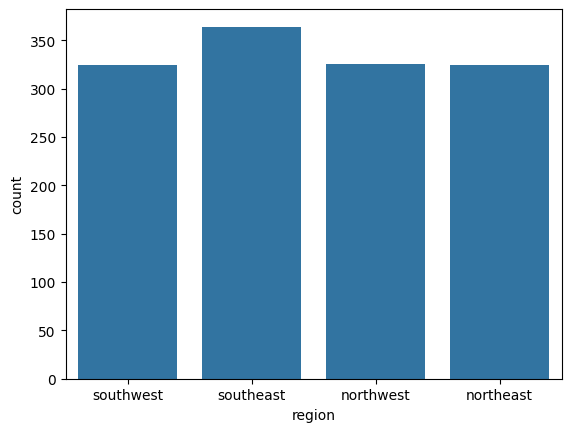

In [ ]:
sns.countplot(x = 'region', data= df)

plt.xlabel('region')
plt.ylabel('count')


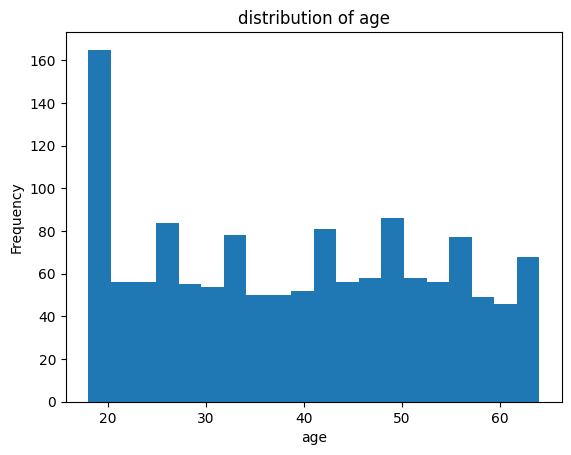

In [ ]:
#histogram
df['age'].plot(kind = "hist", bins = 20)

plt.xlabel('age')
plt.title('distribution of age')
plt.show()

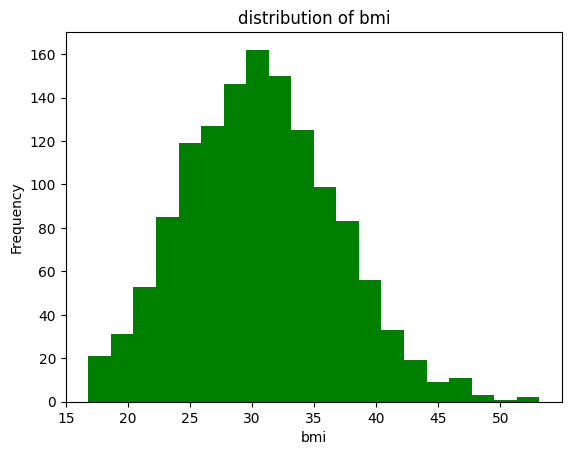

In [ ]:
df['bmi'].plot(kind = "hist", bins = 20, color="g")

plt.xlabel('bmi')
plt.title('distribution of bmi')
plt.show()

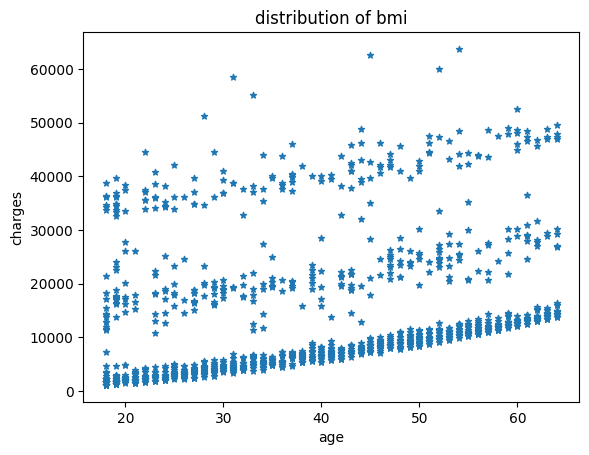

In [ ]:
df.plot(kind = "scatter", x = "age", y= "charges", marker= "*")

plt.xlabel('age')
plt.title('distribution of bmi')
plt.show()

### Eliminating Outliers using the Interquartile Range (IQR) Method

Outliers are data points that lie an abnormal distance from other values in a random sample. In a box plot, these are typically shown as individual points beyond the 'whiskers'.

To eliminate them, we'll use the Interquartile Range (IQR) method:
1.  **Calculate Q1 and Q3**: The first quartile (Q1) is the 25th percentile, and the third quartile (Q3) is the 75th percentile of the data.
2.  **Calculate IQR**: IQR = Q3 - Q1.
3.  **Define Outlier Bounds**: Any data point falling below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.

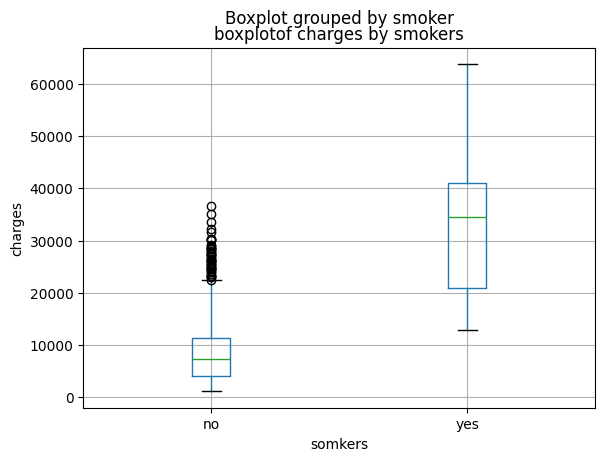

In [ ]:
df.boxplot(column = 'charges', by = 'smoker')
plt.xlabel('somkers')
plt.ylabel('charges')
plt.title('boxplotof charges by smokers')
plt.show()

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'charges'
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to remove outliers from the 'charges' column
df_filtered = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (after removing outliers): {df_filtered.shape}")

Original DataFrame shape: (1335, 7)
Filtered DataFrame shape (after removing outliers): (1196, 7)


Now, let's replot the box plot using the filtered DataFrame to see the effect of outlier removal.

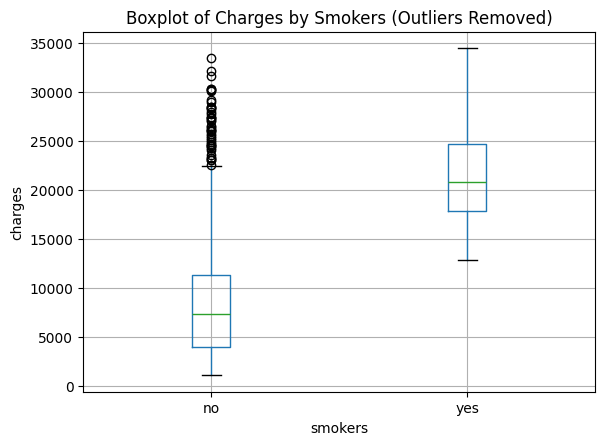

In [ ]:
df_filtered.boxplot(column='charges', by='smoker')
plt.xlabel('smokers')
plt.ylabel('charges')
plt.title('Boxplot of Charges by Smokers (Outliers Removed)')
plt.suptitle('') # Suppress the default suptitle generated by boxplot
plt.show()

In [ ]:
df.replace({'sex': {'male':0, 'female':1}}, inplace= True)
df.replace({'smoker':{'yes':1, 'no':0}}, inplace = True)
df.replace({'region': {'southeast':1, 'southwest':0, 'northeast':2, 'northwest':3}}, inplace= True)

# Display the updated DataFrame info to see the changed data types (if applicable) and head
print("\nDataFrame Info after encoding:")
print(df.info())
print("\nHead of the DataFrame after encoding:")
print(df.head())


DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 1335 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1335 non-null   float64
 1   sex       1335 non-null   int64  
 2   bmi       1335 non-null   float64
 3   children  1335 non-null   float64
 4   smoker    1335 non-null   int64  
 5   region    1335 non-null   int64  
 6   charges   1335 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 83.4 KB
None

Head of the DataFrame after encoding:
    age  sex     bmi  children  smoker  region      charges
0  19.0    1  27.900       0.0       1       0  16884.92400
1  18.0    0  33.770       1.0       0       1   1725.55230
2  28.0    0  33.000       3.0       0       1   4449.46200
3  33.0    0  22.705       0.0       0       3  21984.47061
4  32.0    0  28.880       0.0       0       3   3866.85520


In [ ]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.017829,0.107134,0.041588,-0.024662,-0.000100,0.297196
sex,0.017829,1.000000,-0.048183,-0.017750,-0.075900,0.010376,-0.059511
bmi,0.107134,-0.048183,1.000000,0.010176,0.002765,-0.156689,0.196376
children,0.041588,-0.017750,0.010176,1.000000,0.007276,0.002069,0.066303
smoker,-0.024662,-0.075900,0.002765,0.007276,1.000000,-0.014115,0.789195
region,-0.000100,0.010376,-0.156689,0.002069,-0.014115,1.000000,-0.009659
charges,0.297196,-0.059511,0.196376,0.066303,0.789195,-0.009659,1.000000


<Axes: >

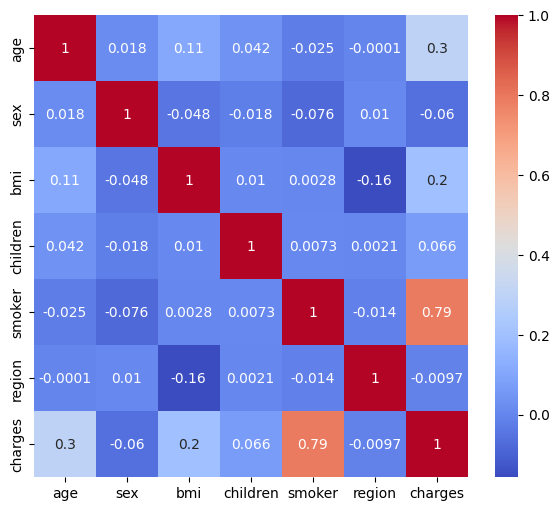

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(df.corr(), annot= True, cmap= 'coolwarm')

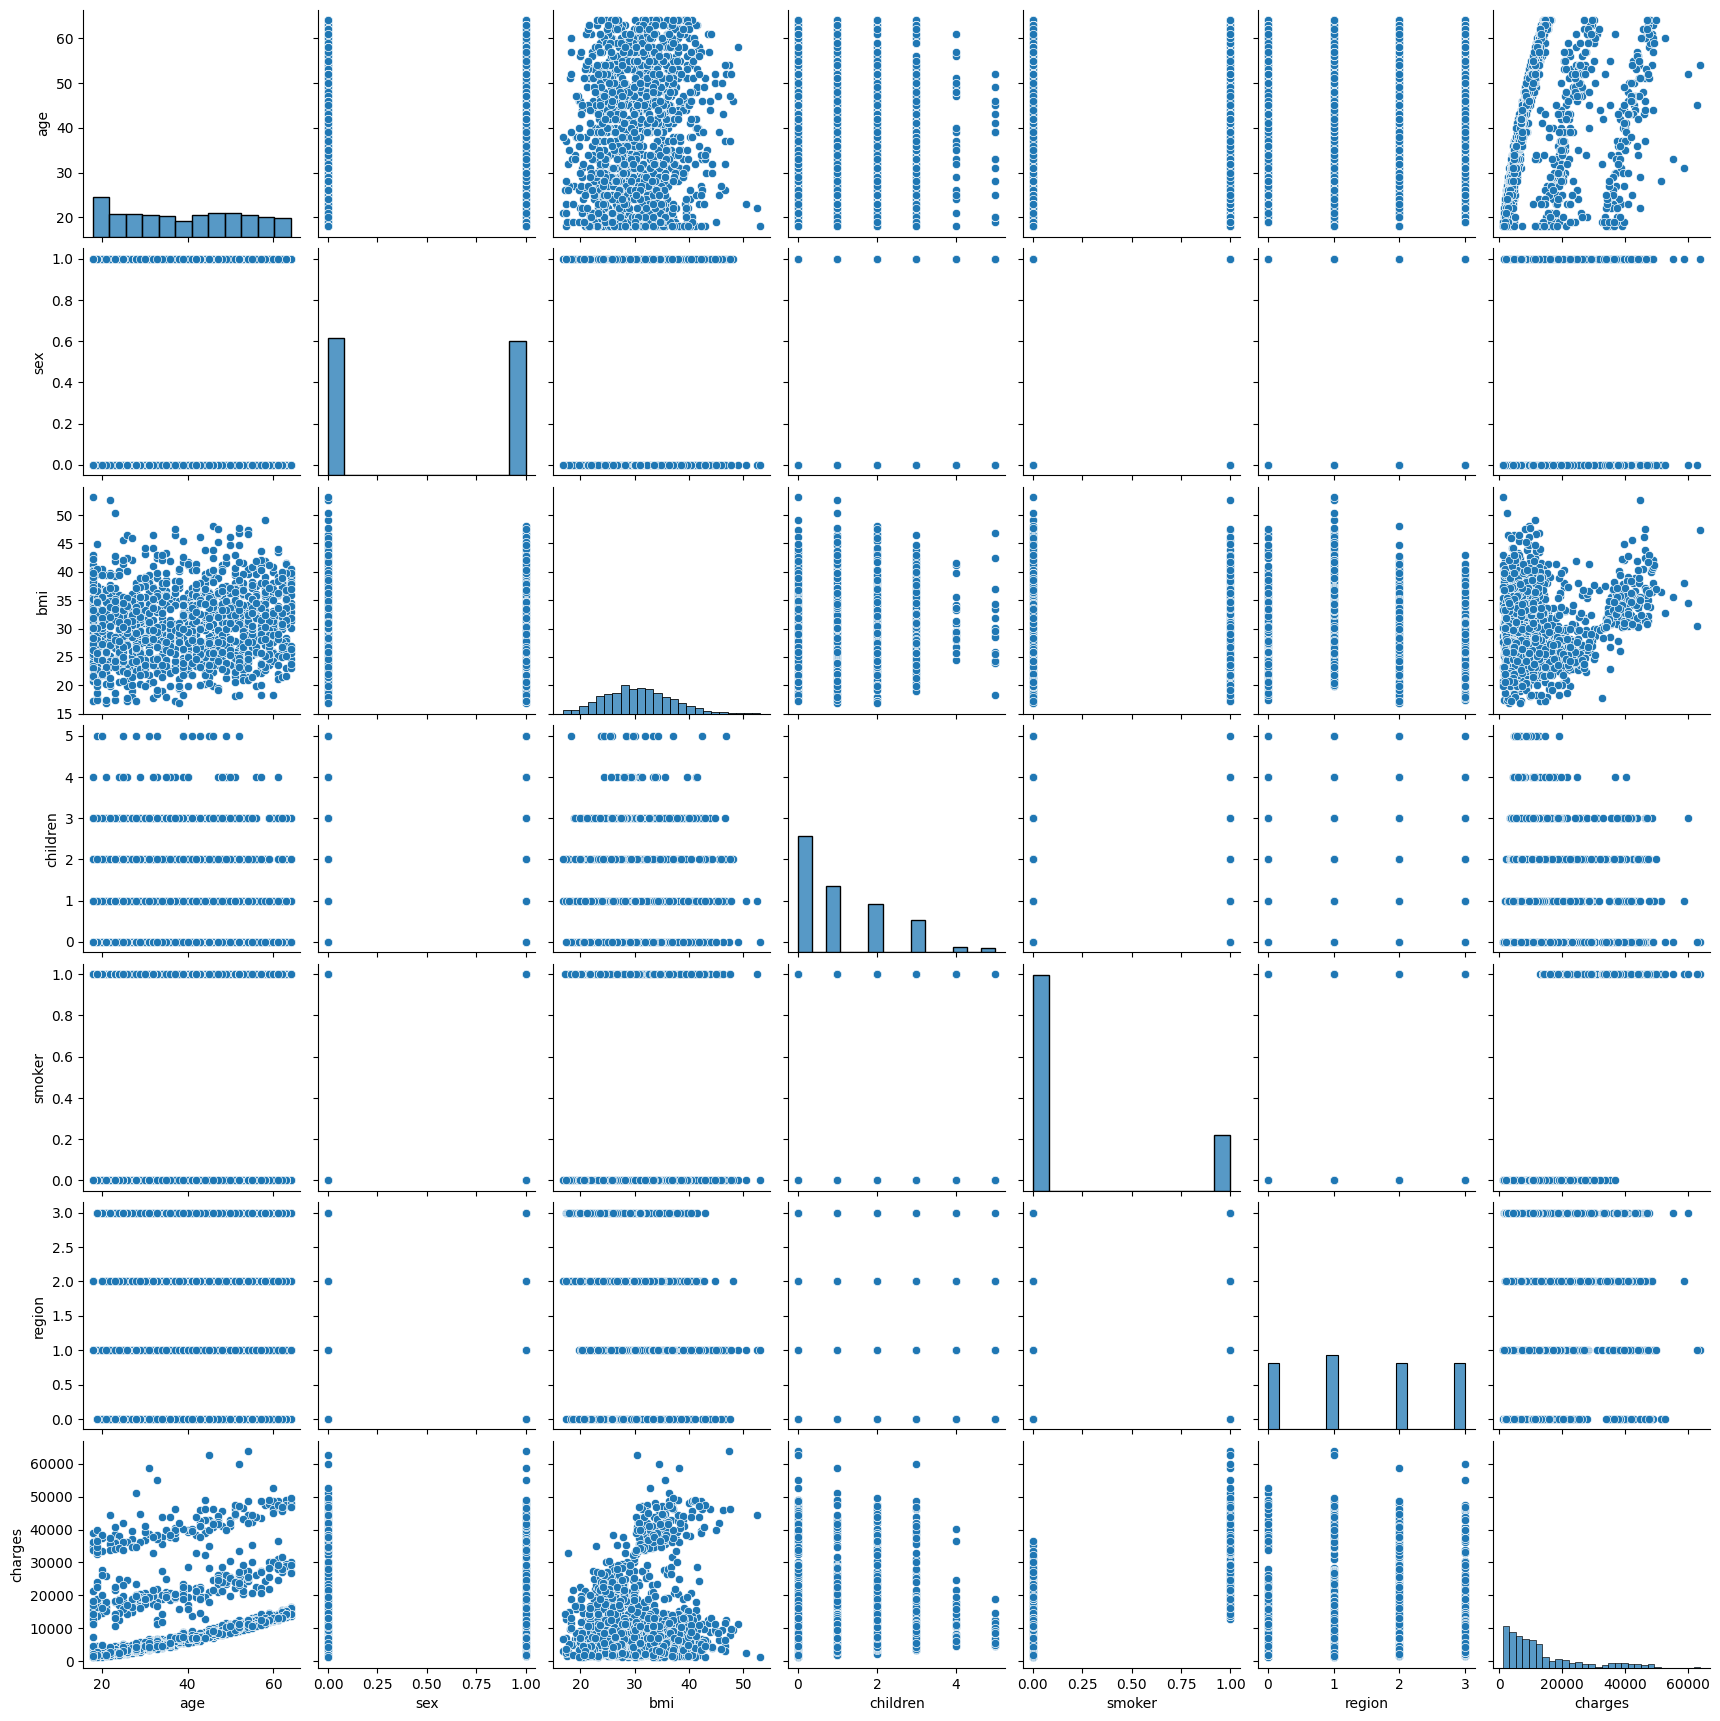

In [ ]:
sns.pairplot(df)

In [12]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder # for feature engineering
from sklearn.model_selection import train_test_split

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor # Note: requires pip install xgboost

from sklearn.metrics import mean_squared_error, mean_absolute_error # for evaluating ml models

In [24]:
import pandas as pd
import os

# Using the selected file as requested
file_path = '/content/insurance - Copy.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Loaded dataset successfully from local copy.")
else:
    # Fallback to direct URL if local copy is missing
    url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
    df = pd.read_csv(url)
    print("Local copy not found. Loaded dataset from URL fallback.")

df

Loaded dataset successfully from local copy.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1334,18,female,31.920,0.0,no,northeast,2205.98080
1335,18,female,36.850,0.0,no,southeast,1629.83350
1336,21,female,25.800,0.0,no,southwest,2007.94500
1337,61,female,29.070,0.0,yes,northwest,29141.36030


In [11]:
df.describe()

,bmi,children,charges
count,1338.000000,1338.000000,1338.000000
mean,30.663397,1.094918,13270.422265
std,6.098187,1.205493,12110.011237
min,15.960000,0.000000,1121.873900
25%,26.296250,0.000000,4740.287150
50%,30.400000,1.000000,9382.033000
75%,34.693750,2.000000,16639.912515
max,53.130000,5.000000,63770.428010


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1339 non-null   object 
 1   sex       1337 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   float64
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), object(4)
memory usage: 73.4+ KB


In [13]:
df.shape

(1339, 7)

In [14]:
df['region'].value_counts()

,count
region,
southeast,364
northwest,325
southwest,324
northeast,324


In [15]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [16]:
df['sex'].value_counts()

,count
sex,
male,676
female,661


**EXPOLOTARY DATA ANALYSIS(EDA)**
.BOX plot
.bar chart
.pie chart
.violinplot
.hist chart
.scatter plot
.heatmap chart
.pairplot

In [17]:
# checking duplicate values
df.duplicated().value_counts()

,count
False,1338
True,1


In [18]:
# droping duplicate values
df.drop_duplicates(inplace=True)

In [19]:
df.shape

(1338, 7)

In [20]:
df.size

9366

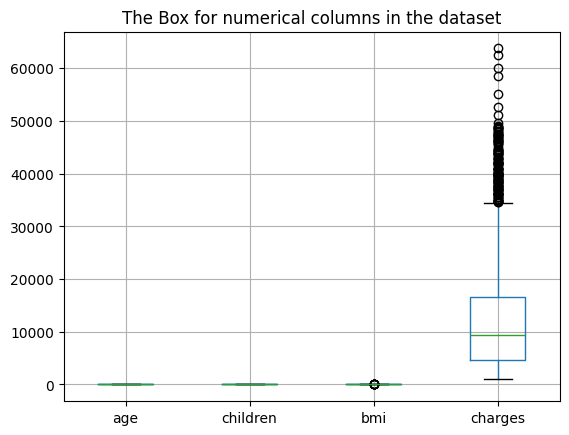

In [25]:
# Clean the 'age' column to ensure it is numeric and drop any NaNs
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df_clean = df.dropna(subset=['age', 'children', 'bmi', 'charges'])

# box plot
df_clean.boxplot(column=['age', 'children', 'bmi', 'charges'])
plt.title("The Box for numerical columns in the dataset")
plt.show()

In [26]:
dc = df[(df['charges']<21000) & (df['bmi']<46)] # removing the outliers in charges coloumn and bmi

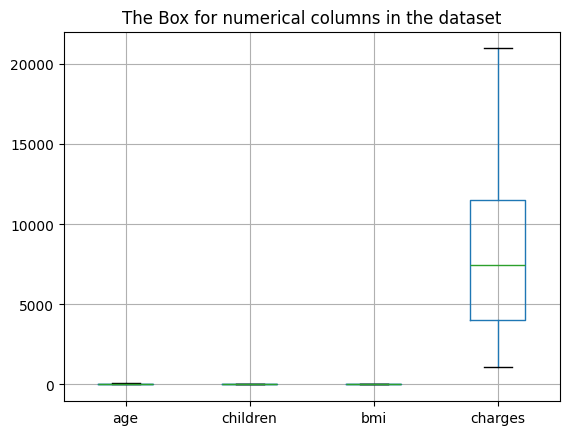

In [27]:
dc.boxplot(column=['age', 'children', 'bmi', 'charges'])
plt.title("The Box for numerical columns in the dataset")
plt.show()

In [28]:
dc.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.90,0.0,yes,southwest,16884.9240
1,18.0,male,33.77,1.0,no,southeast,1725.5523
2,28.0,male,33.00,3.0,no,southeast,4449.4620
4,32.0,male,28.88,0.0,no,northwest,3866.8552
5,31.0,female,25.74,0.0,no,southeast,3756.6216


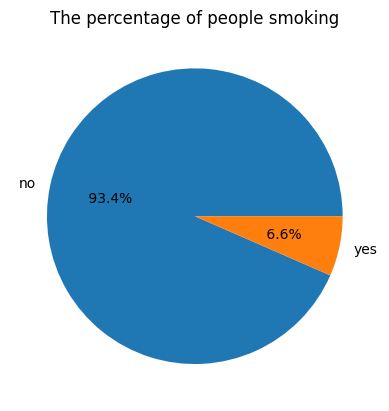

In [29]:
smoker_count = dc['smoker'].value_counts()
#plot the pie chart
plt.pie( smoker_count, labels = smoker_count.index , autopct = '% 1.1f%%')
plt.title("The percentage of people smoking")
plt.show()

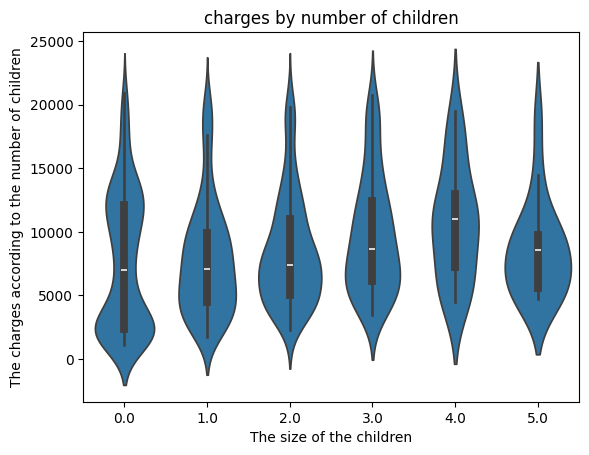

In [30]:
sns.violinplot(x=dc['children'], y = dc['charges'])

plt.xlabel("The size of the children")
plt.ylabel("The charges according to the number of children")

plt.title("charges by number of children")
plt.show()

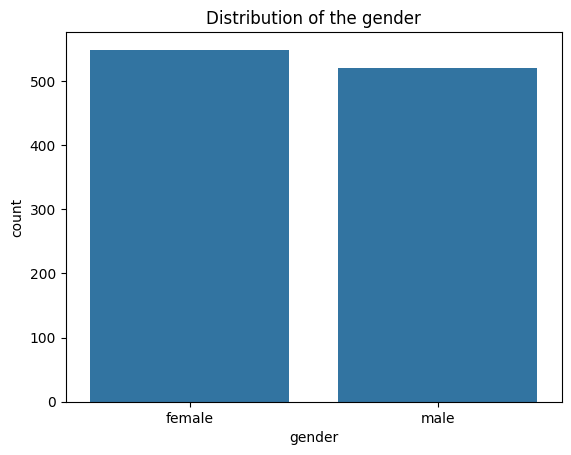

In [31]:
sns.countplot(x = 'sex', data= dc)

plt.xlabel('gender')
plt.ylabel('count')

plt.title("Distribution of the gender")
plt.show()

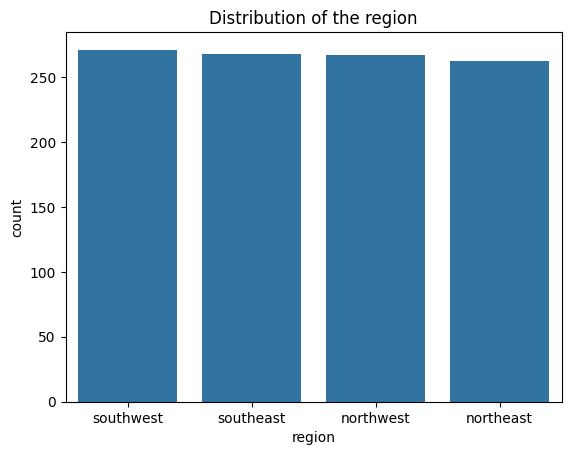

In [32]:
sns.countplot(x = 'region', data= dc)

plt.xlabel('region')
plt.ylabel('count')

plt.title("Distribution of the region")
plt.show()

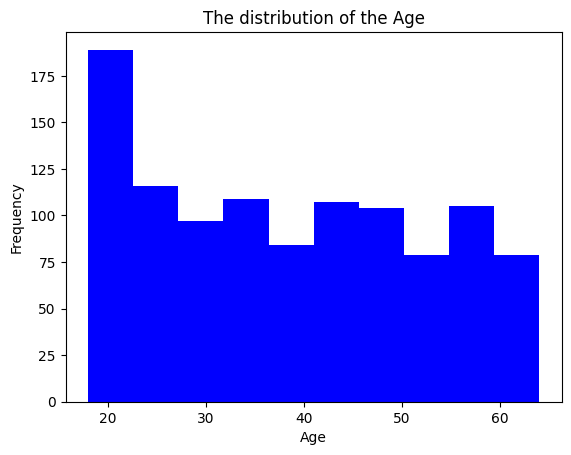

In [68]:
#histogram
dc['age'].plot(kind = 'hist', bins = 10, color = "b")

plt.xlabel("Age")
plt.title("The distribution of the Age")
plt.show()

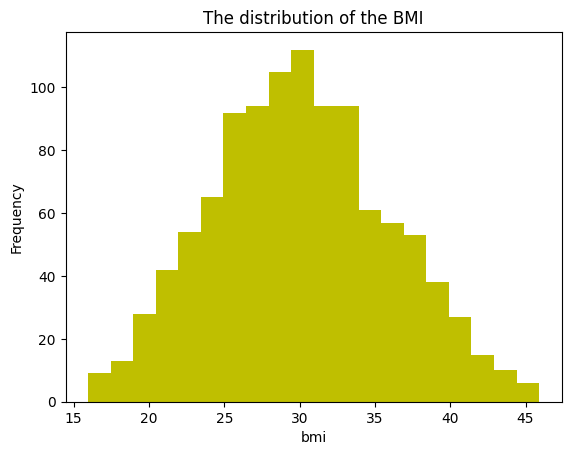

In [69]:
#histogram
dc['bmi'].plot(kind = 'hist', bins = 20, color = "y")

plt.xlabel("bmi")
plt.title("The distribution of the BMI")
plt.show()

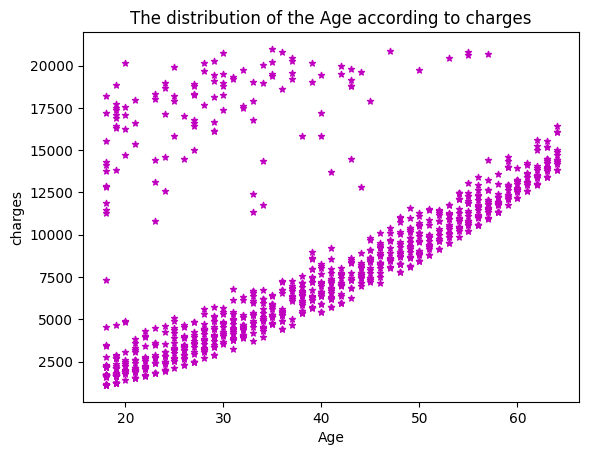

In [70]:
#histogram
dc.plot(kind = 'scatter', x = "age", y= "charges", marker = "*", color = "m")

plt.xlabel("Age")
plt.ylabel("charges")
plt.title("The distribution of the Age according to charges")
plt.show()

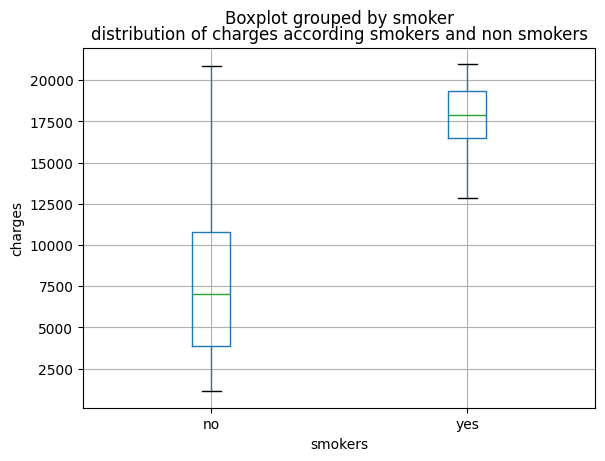

In [36]:
#boxplot according to smoker vs non smoker

dc.boxplot(column= 'charges', by= 'smoker')
plt.xlabel('smokers')
plt.ylabel('charges')

plt.title("distribution of charges according smokers and non smokers")
plt.show()

**Feature Engineering**

Creating new feature such as Age groups

In [37]:
#Creating new feature such as Age groups
dc['age_group'] = pd.cut(dc['age'], bins=[0, 25, 40, 60, dc['age'].max()], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])
dc.sample(10)

/tmp/ipykernel_1293/515314127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dc['age_group'] = pd.cut(dc['age'], bins=[0, 25, 40, 60, dc['age'].max()], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])


,age,sex,bmi,children,smoker,region,charges,age_group
982,31.0,male,25.900,3.0,yes,southwest,19199.94400,Adult
999,36.0,female,26.885,0.0,no,northwest,5267.81815,Adult
241,33.0,female,22.135,1.0,no,northeast,5354.07465,Adult
392,48.0,male,31.445,1.0,no,northeast,8964.06055,Middle-aged
798,58.0,female,33.100,0.0,no,southwest,11848.14100,Middle-aged
1184,23.0,female,28.490,1.0,yes,southeast,18328.23810,Young
174,24.0,female,33.345,0.0,no,northwest,2855.43755,Young
1204,18.0,female,27.280,3.0,yes,southeast,18223.45120,Young
1,18.0,male,33.770,1.0,no,southeast,1725.55230,Young
548,25.0,female,28.595,0.0,no,northeast,3213.62205,Young


Feature encoding-Handling categorical **variables**
One-hot encoding for the 'region'column

In [38]:
dc = pd.get_dummies(dc, columns=['region'], prefix='region', dtype=int)
dc.sample(5)

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest
375,23.0,female,28.310,0.0,yes,18033.96790,Young,0,1,0,0
1162,30.0,male,38.830,1.0,no,18963.17192,Adult,0,0,1,0
51,21.0,female,33.630,2.0,no,3579.82870,Young,0,1,0,0
168,19.0,female,31.825,1.0,no,2719.27975,Young,0,1,0,0
654,59.0,female,35.200,0.0,no,12244.53100,Middle-aged,0,0,1,0


In [39]:
#encoding of some columns
label_encoder = LabelEncoder()
dc['smoker_encoded'] = label_encoder.fit_transform(dc['smoker'])
dc.sample(5)

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
231,59.0,female,27.83,3.0,no,14001.2867,Middle-aged,0,0,1,0,0
302,56.0,female,37.51,2.0,no,12265.5069,Middle-aged,0,0,1,0,0
894,62.0,male,32.11,0.0,no,13555.0049,Senior,1,0,0,0,0
284,52.0,female,31.20,0.0,no,9625.9200,Middle-aged,0,0,0,1,0
511,27.0,male,33.66,0.0,no,2498.4144,Adult,0,0,1,0,0


In [40]:
#

# sex column
dc.replace({'sex':{'male':0, 'female': 1}}, inplace= True)

# smokers column
dc.replace({'smoker':{'no': 0, 'yes':1}}, inplace= True)

# region column

#dc.replace({'region':{'southeast':0, 'southwest': 1, 'northeast':2, 'northwest': 3}}, inplace = True)

/tmp/ipykernel_1293/3999507527.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dc.replace({'sex':{'male':0, 'female': 1}}, inplace= True)
/tmp/ipykernel_1293/3999507527.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dc.replace({'smoker':{'no': 0, 'yes':1}}, inplace= True)


In [41]:
dc

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
0,19.0,1,27.90,0.0,1.0,16884.9240,Young,0,0,0,1,1
1,18.0,0,33.77,1.0,0.0,1725.5523,Young,0,0,1,0,0
2,28.0,0,33.00,3.0,0.0,4449.4620,Adult,0,0,1,0,0
4,32.0,0,28.88,0.0,0.0,3866.8552,Adult,0,1,0,0,0
5,31.0,1,25.74,0.0,0.0,3756.6216,Adult,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52.0,1,44.70,3.0,0.0,11411.6850,Middle-aged,0,0,0,1,0
1333,50.0,0,30.97,3.0,0.0,10600.5483,Middle-aged,0,1,0,0,0
1334,18.0,1,31.92,0.0,0.0,2205.9808,Young,1,0,0,0,0
1335,18.0,1,36.85,0.0,0.0,1629.8335,Young,0,0,1,0,0


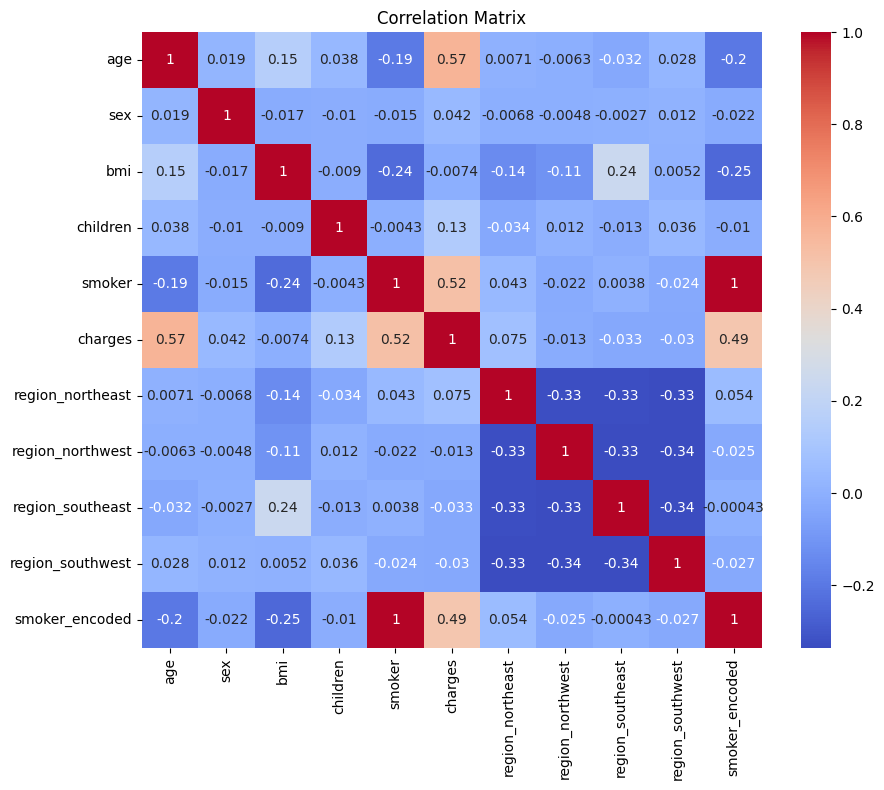

Relevant features based on correlation:
['age', 'smoker', 'smoker_encoded']


In [42]:
numr_cols = [x for x in dc.columns if x not in ['age_group']]
corr_matrix = dc[numr_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Identify relevant features based on correlation
threshold = 0.3
relevant_features = corr_matrix[(corr_matrix['charges'].abs() > threshold) & (corr_matrix.index != 'charges')].index.tolist()
print("Relevant features based on correlation:")
print(relevant_features)

**Modelling**

In [48]:
#Modelling
# Select the relevant features
X = dc[['age', 'smoker_encoded']]
y = dc['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

7929303.615523369
1656.1677612242993


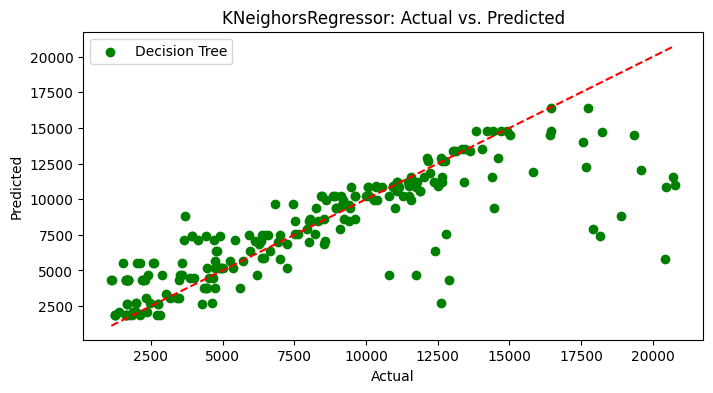

In [51]:
# KNeighborsRegressor
dt_model = KNeighborsRegressor()
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_predictions)
print(dt_mse)
dt_mae = mean_absolute_error(y_test, dt_predictions)
print(dt_mae)

# Plot actual vs. predicted values for Decision Tree
plt.figure(figsize=(8, 4))
plt.scatter(y_test, dt_predictions, color='green', label='Decision Tree')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('KNeighorsRegressor: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

AdaBoost MSE: 7162563.13341059
AdaBoost MAE: 1602.5794676914531


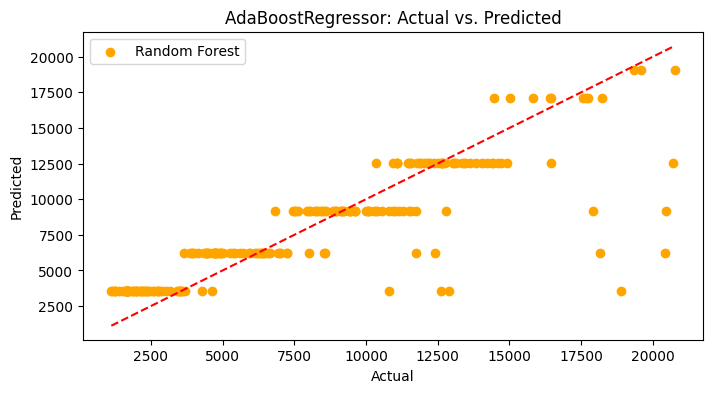

In [54]:
# Ensenble
rf_model = AdaBoostRegressor()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
print("AdaBoost MSE:", rf_mse)
print("AdaBoost MAE:", rf_mae)

# Plot actual vs. predicted values for Random Forest
plt.figure(figsize=(8, 4))
plt.scatter(y_test, rf_predictions, color='orange', label='Random Forest')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('AdaBoostRegressor: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

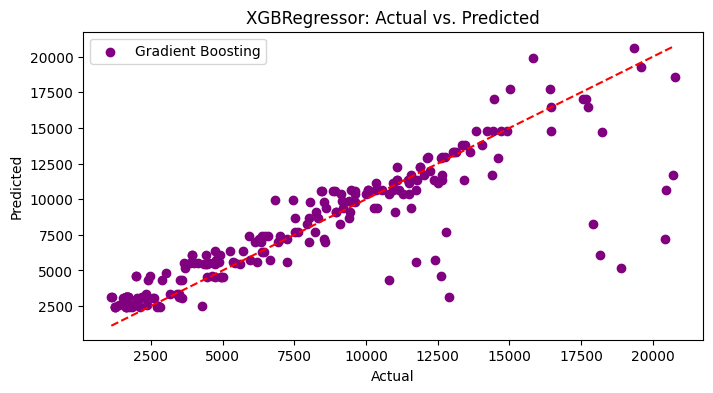

In [55]:
# Xgboost
gb_model = XGBRegressor()
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_mae = mean_absolute_error(y_test, gb_predictions)

# Plot actual vs. predicted values for Gradient Boosting
plt.figure(figsize=(8, 4))
plt.scatter(y_test, gb_predictions, color='purple', label='Gradient Boosting')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('XGBRegressor: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

In [57]:
# Print the evaluation metrics
print("KNeighborsRegressor - MSE: ", dt_mse)
print("KNeighborsRegressor - MAE: ", dt_mae)
print("AdaBoostRegressor - MSE: ", rf_mse)
print("AdaBoostRegressor - MAE: ", rf_mae)
print("XGBRegressor - MSE: ", gb_mse)
print("XGBRegressor - MAE: ", gb_mae)

KNeighborsRegressor - MSE:  7929303.615523369
KNeighborsRegressor - MAE:  1656.1677612242993
AdaBoostRegressor - MSE:  7162563.13341059
AdaBoostRegressor - MAE:  1602.5794676914531
XGBRegressor - MSE:  6383141.078702178
XGBRegressor - MAE:  1388.7075671225177


##Feature Importance##

In [60]:
# KNeighborsRegressor does not have feature_importances_ as it is a distance-based model.
print("KNeighborsRegressor:")
print("Distance-based model (No native feature importances attribute available)")
print()

# Random Forest / AdaBoost
print("AdaBoostRegressor:")
importance_rf = rf_model.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance_rf[i]:.4f}")
print()

# Gradient Boosting / XGBoost
print("XGBRegressor:")
importance_gb = gb_model.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance_gb[i]:.4f}")
print()

KNeighborsRegressor:
Distance-based model (No native feature importances attribute available)

AdaBoostRegressor:
age: 0.5681
smoker_encoded: 0.4319

XGBRegressor:
age: 0.2640
smoker_encoded: 0.7360



In [61]:
dc

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
0,19.0,1,27.90,0.0,1.0,16884.9240,Young,0,0,0,1,1
1,18.0,0,33.77,1.0,0.0,1725.5523,Young,0,0,1,0,0
2,28.0,0,33.00,3.0,0.0,4449.4620,Adult,0,0,1,0,0
4,32.0,0,28.88,0.0,0.0,3866.8552,Adult,0,1,0,0,0
5,31.0,1,25.74,0.0,0.0,3756.6216,Adult,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52.0,1,44.70,3.0,0.0,11411.6850,Middle-aged,0,0,0,1,0
1333,50.0,0,30.97,3.0,0.0,10600.5483,Middle-aged,0,1,0,0,0
1334,18.0,1,31.92,0.0,0.0,2205.9808,Young,1,0,0,0,0
1335,18.0,1,36.85,0.0,0.0,1629.8335,Young,0,0,1,0,0


In [63]:
# Calculate the correlation matrix only for numeric columns to avoid string conversion errors with 'age_group'
dc.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
age,1.000000,0.018642,0.154781,0.037945,-0.191431,0.570635,0.007075,-0.006263,-0.031852,0.028251,-0.196385
sex,0.018642,1.000000,-0.017262,-0.010117,-0.015012,0.041562,-0.006761,-0.004849,-0.002743,0.012150,-0.021904
bmi,0.154781,-0.017262,1.000000,-0.008993,-0.241405,-0.007442,-0.135577,-0.109169,0.240090,0.005243,-0.251331
children,0.037945,-0.010117,-0.008993,1.000000,-0.004260,0.134098,-0.033587,0.011983,-0.012919,0.036053,-0.010412
smoker,-0.191431,-0.015012,-0.241405,-0.004260,1.000000,0.516055,0.043082,-0.021844,0.003791,-0.024016,1.000000
charges,0.570635,0.041562,-0.007442,0.134098,0.516055,1.000000,0.075187,-0.013410,-0.032636,-0.029757,0.492185
region_northeast,0.007075,-0.006761,-0.135577,-0.033587,0.043082,0.075187,1.000000,-0.328763,-0.329583,-0.332045,0.054328
region_northwest,-0.006263,-0.004849,-0.109169,0.011983,-0.021844,-0.013410,-0.328763,1.000000,-0.333749,-0.336242,-0.025347
region_southeast,-0.031852,-0.002743,0.240090,-0.012919,0.003791,-0.032636,-0.329583,-0.333749,1.000000,-0.337081,-0.000429
region_southwest,0.028251,0.012150,0.005243,0.036053,-0.024016,-0.029757,-0.332045,-0.336242,-0.337081,1.000000,-0.027500


<Axes: >

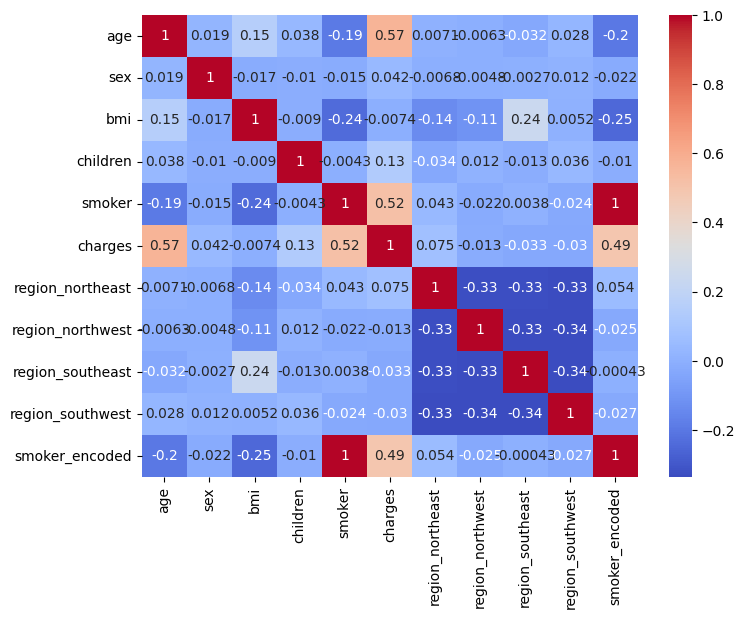

In [65]:
#heatmap display

plt.figure(figsize=(8,6))
sns.heatmap(dc.corr(numeric_only=True), annot= True, cmap = 'coolwarm')

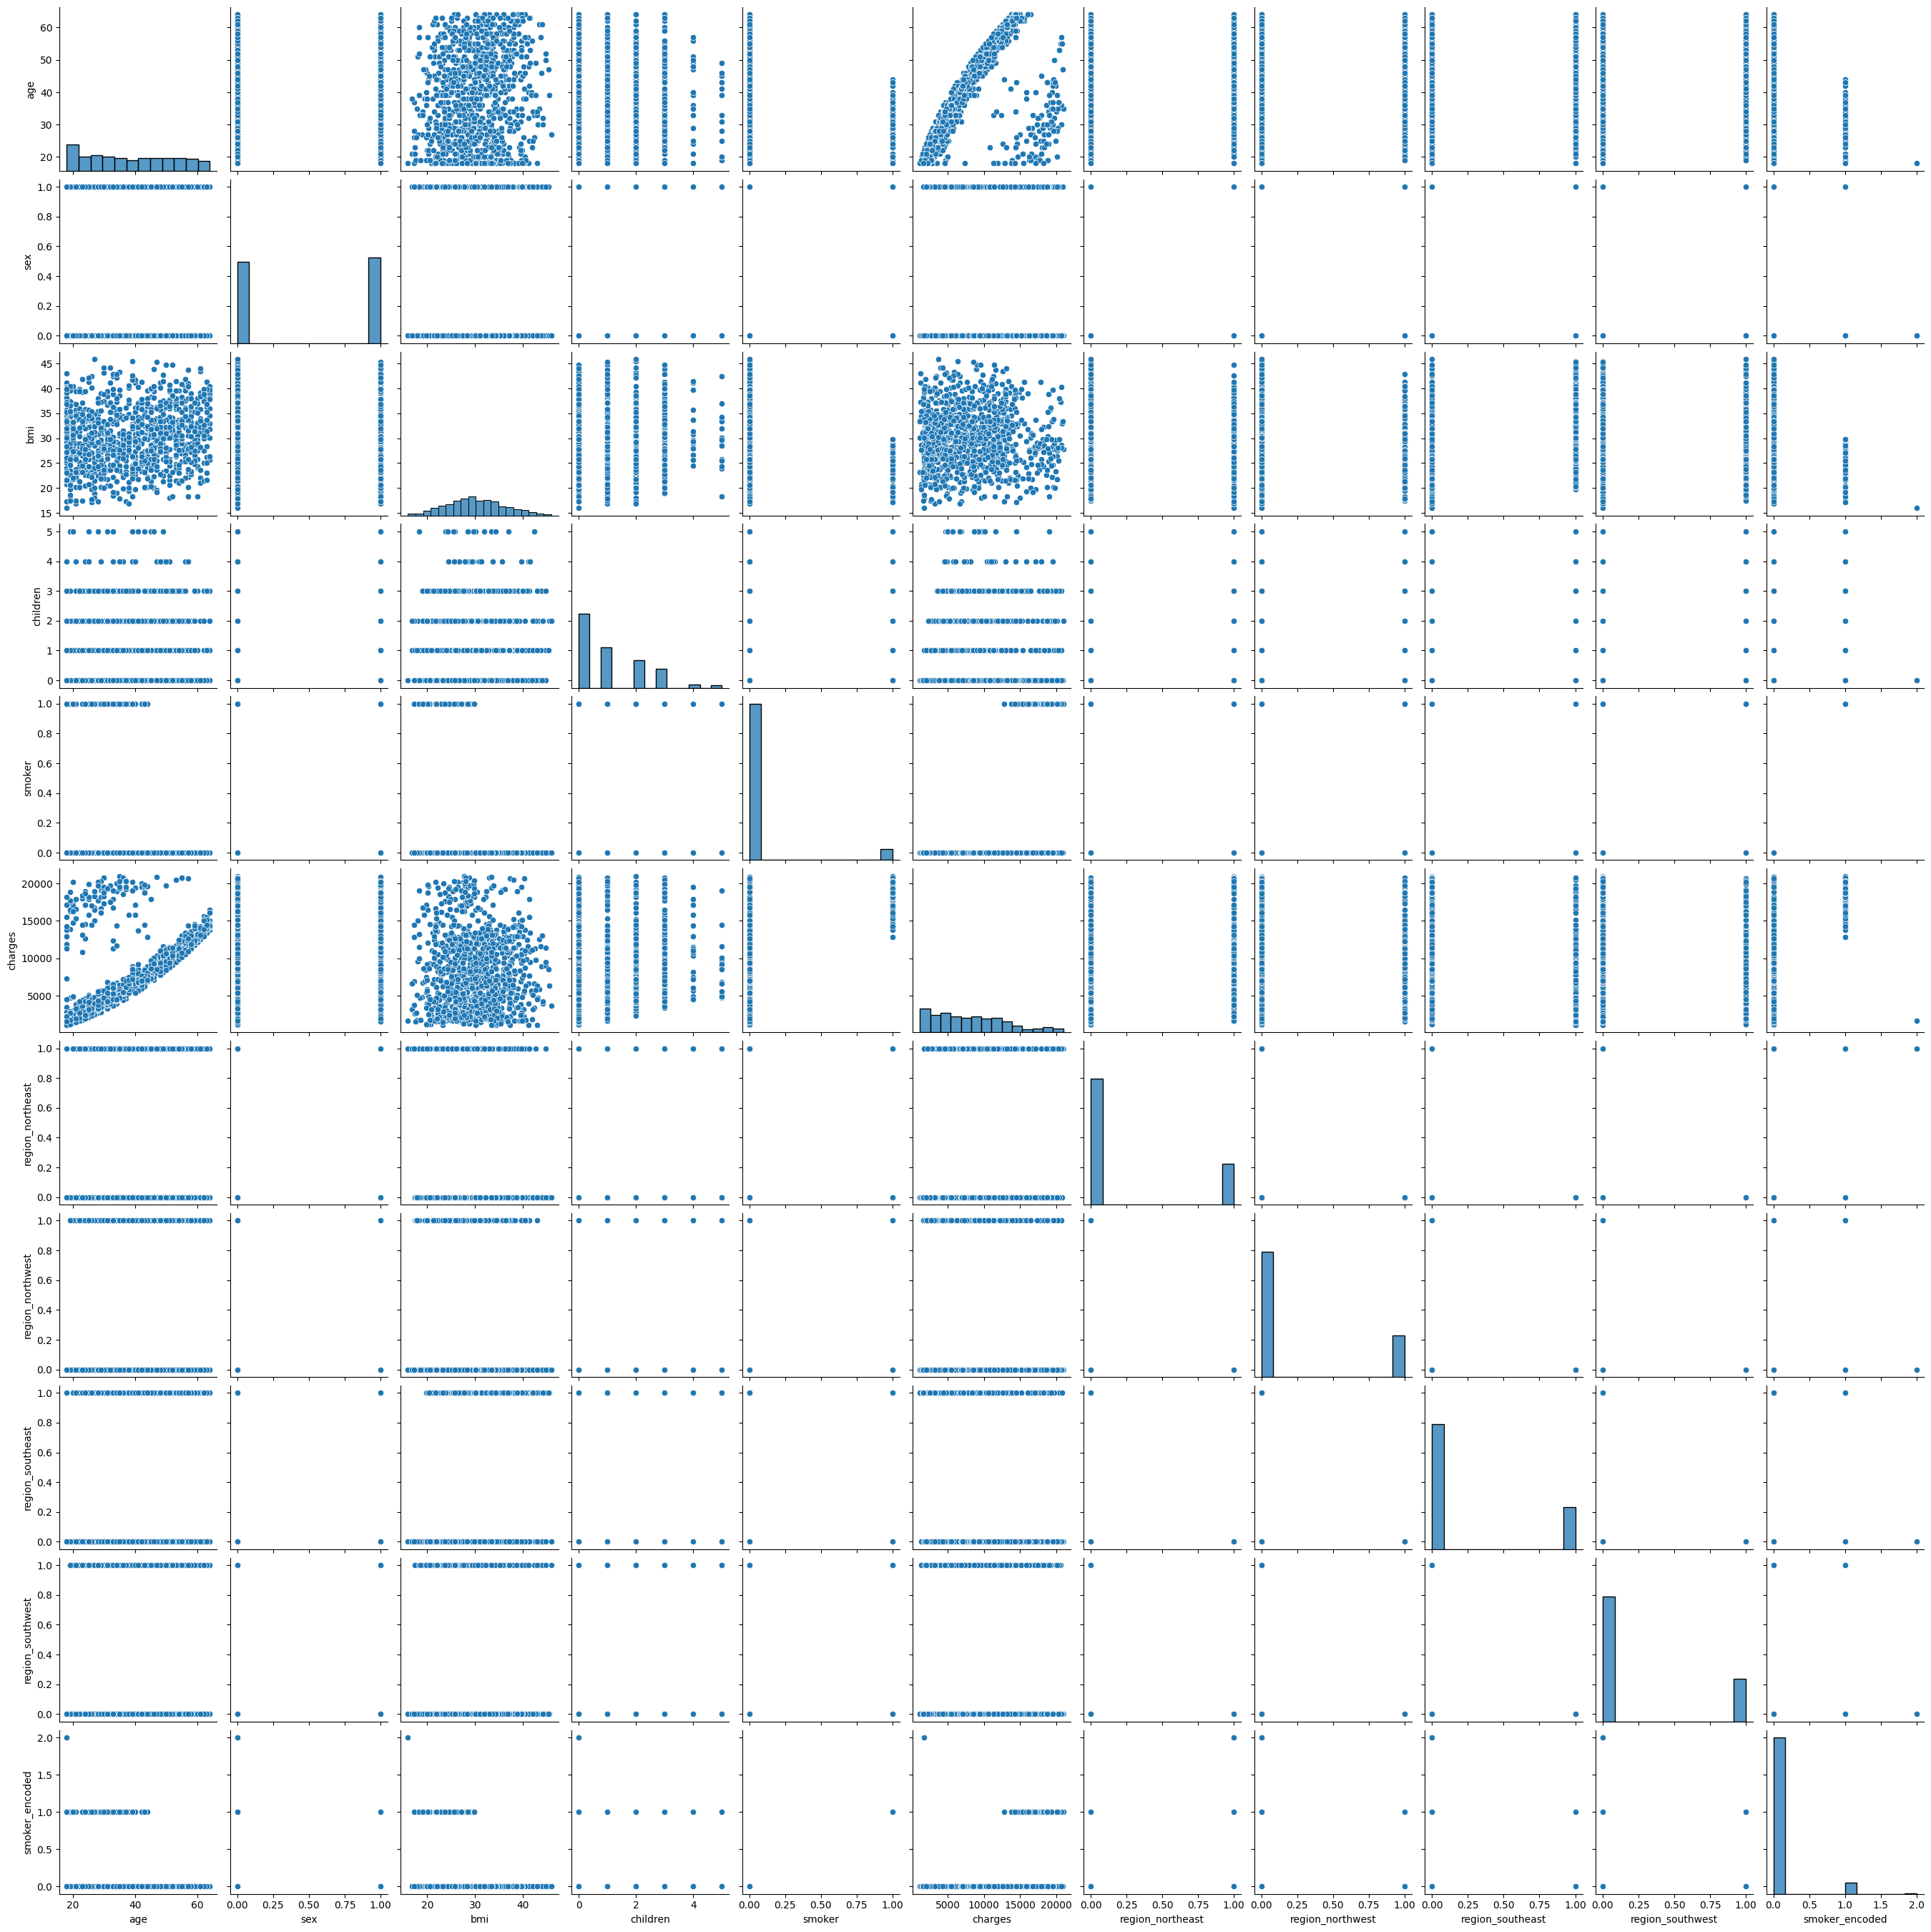

In [66]:
sns.pairplot(dc)